# Thin-sheet IE forward modeling (WSHEET20, Python)

Vertical thin sheet at x = 500 m (200 x 200 m, 0.1 m thick) in a 10 ohm-m whole space, VMD source at the origin, 201 receivers along x = 0-1000 m at z = 0.75 m, f = 20 kHz.

Three runs: conductive sheet (rho = 1e-5 ohm-m, tau ~ 1e4 S), zero-contrast sheet (rho = 10.000001 ohm-m), and background without the sheet. Outputs: `h-field-IE-{conductive,zerocontrast,background}-20kHz.dat`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import lu_factor, lu_solve

In [2]:
class CommonBlocks:
    """Mirrors the Fortran COMMON blocks of WSHEET20.F
    (/geo/, /locate/, /prop/, /parm/, /txrx/, /const/, /cell/, /simp1/, /simp2/)
    All 1-based Fortran arrays are padded by one element; index 0 is unused."""
    def __init__(self):
        # /geo/ alpha(2), beta(2), aa(2), bb(2)
        self.alpha = np.zeros(3); self.beta = np.zeros(3)
        self.aa    = np.zeros(3); self.bb   = np.zeros(3)
        # /locate/ x_top(2), y_top(2), z_top(2)
        self.x_top = np.zeros(3); self.y_top = np.zeros(3); self.z_top = np.zeros(3)
        # /prop/ admit, imped, wave_s, tau(2)
        self.admit = 0j; self.imped = 0j; self.wave_s = 0j
        self.tau = np.zeros(3, dtype=complex)
        # /parm/ omega, pi
        self.omega = 0.0; self.pi = 4.0*np.arctan(1.0)
        # /txrx/ ns_type, ns_dir, angle
        self.ns_type = 0; self.ns_dir = 0; self.angle = 0.0
        # /const/ i_no, c_null, conv
        self.i_no = complex(0.0, 1.0); self.c_null = complex(0.0, 0.0)
        self.conv = self.pi/180.0
        # /cell/ na(2), nb(2), max_n
        self.na = np.zeros(3, dtype=int); self.nb = np.zeros(3, dtype=int)
        self.max_n = 0
        # /simp1/ ikk, i_d      /simp2/ xx, yy, zz
        self.ikk = 0j; self.i_d = 0
        self.xx = 0.0; self.yy = 0.0; self.zz = 0.0

cb = CommonBlocks()

In [3]:
def polint(xa, ya, x):
    """Polynomial interpolation/extrapolation (Numerical Recipes POLINT), complex y."""
    n = len(xa)
    c = list(ya); d = list(ya)
    ns = 0
    dif = abs(x - xa[0])
    for i in range(1, n):
        dift = abs(x - xa[i])
        if dift < dif:
            ns = i; dif = dift
    y = ya[ns]
    ns -= 1
    dy = 0j
    for m in range(1, n):
        for i in range(n - m):
            ho = xa[i] - x
            hp = xa[i + m] - x
            w = c[i + 1] - d[i]
            den = ho - hp
            den = w / den
            d[i] = hp * den
            c[i] = ho * den
        if 2*(ns + 1) < (n - m):
            dy = c[ns + 1]
        else:
            dy = d[ns]
            ns -= 1
        y = y + dy
    return y, dy


def trapzd(func, a, b, s, n):
    """n-th stage of trapezoidal-rule refinement (Numerical Recipes TRAPZD).
    The interior points of each refinement stage are evaluated as one NumPy
    vector call to `func` (same sums, same results as the scalar loop)."""
    if n == 1:
        return 0.5*(b - a)*(func(a) + func(b))
    it = 2**(n - 2)
    tnm = float(it)
    delta = (b - a)/tnm
    x = a + 0.5*delta + delta*np.arange(it)
    total = np.sum(func(x))
    return 0.5*(s + (b - a)*total/tnm)


def qromb(func, a, b, eps=1.0e-6, jmax=20, k=5):
    """Romberg integration of func over [a,b] (Numerical Recipes QROMB),
    complex-capable."""
    if a == b:
        return 0j
    h = np.zeros(jmax + 1)
    s = np.zeros(jmax + 1, dtype=complex)
    h[0] = 1.0
    sval = 0j
    ss = 0j
    for j in range(1, jmax + 1):
        sval = trapzd(func, a, b, sval, j)
        s[j - 1] = sval
        if j >= k:
            ss, dss = polint(h[j - k:j], s[j - k:j], 0.0)
            if abs(dss) <= eps*abs(ss) or abs(dss) < 1.0e-30:
                return ss
        if j < jmax:
            h[j] = 0.25*h[j - 1]
    return ss


# --- bi-cubic spline quadrature (equivalent of IMSL DBCQDU) -----------------
# The spline integral is a linear functional of the gridded data, so for a
# given grid layout (relative node offsets + full-span limits) the integral is
# sum(W * fdata) with a fixed weight matrix W.  W is computed once per layout
# with RectBivariateSpline itself (unit-vector data), then reused.  This gives
# results identical to calling RectBivariateSpline(...).integral(...) for
# every cell, at a small fraction of the cost.
_dbcqdu_wcache = {}

def _dbcqdu_weights(x, y):
    nx, ny = len(x), len(y)
    W = np.zeros((nx, ny))
    e = np.zeros((nx, ny))
    for i in range(nx):
        for j in range(ny):
            e[i, j] = 1.0
            sp = RectBivariateSpline(x, y, e, kx=3, ky=3)
            W[i, j] = sp.integral(x[0], x[-1], y[0], y[-1])
            e[i, j] = 0.0
    return W


def dbcqdu(fdata, x, y, a, b, c, d):
    """Bi-cubic spline quadrature of gridded data (equivalent of IMSL DBCQDU):
    fits a bi-cubic spline to fdata(x_i, y_j) and integrates it over
    [a,b] x [c,d].  Returns (integral, ier)."""
    try:
        full_span = (abs(a - x[0]) + abs(b - x[-1])
                     + abs(c - y[0]) + abs(d - y[-1])) < 1.0e-9*(abs(x[-1]-x[0]) + abs(y[-1]-y[0]) + 1.0e-30)
        if full_span:
            key = (tuple(np.round(x - x[0], 10)), tuple(np.round(y - y[0], 10)))
            W = _dbcqdu_wcache.get(key)
            if W is None:
                W = _dbcqdu_weights(x - x[0], y - y[0])
                _dbcqdu_wcache[key] = W
            return float(np.sum(W*fdata)), 0
        sp = RectBivariateSpline(x, y, fdata, kx=3, ky=3)
        return sp.integral(a, b, c, d), 0
    except Exception:
        return 0.0, 1


def ludcmp(a):
    """LU decomposition with partial pivoting (replaces NR LUDCMP; LAPACK-based)."""
    lu, piv = lu_factor(a)
    return lu, piv


def lubksb(lu, piv, b):
    """Back-substitution for the LU-decomposed system (replaces NR LUBKSB)."""
    return lu_solve((lu, piv), b)

In [4]:
def facto(nmax):
    """real function facto(nmax) -- factorial."""
    fact = 1.0
    for i in range(1, nmax + 1):
        fact = fact * float(i)
    return fact


def ddcos(arg):
    """real function ddcos(arg) -- cosine forced to exactly 0 near 90 degrees."""
    pi2 = cb.pi / 2.0
    diff = abs(pi2 - arg)
    if diff < 1.0e-2:
        return 0.0
    return np.cos(arg)


def cole(z_l, z_h, tau_cc, alpha_cc):
    """complex function cole -- Cole-Cole relaxation model."""
    i_om = complex(0.0, 1.0) * cb.omega
    if (z_l < z_h) or (alpha_cc > 1.0):
        raise SystemExit('>> INVALID COLE-COLE PARAMETERS !!')
    if tau_cc < 1.0e-12:
        return complex(z_l, 0.0)
    return z_h + (z_l - z_h) / (1.0 + (i_om*tau_cc)**alpha_cc)


def deriv(ab):
    """complex function deriv(ab) -- whole-space Green's function kernel
    pot = exp(-ikr)/r                         (i_d = 0)
    or its derivative form pot*(1+ikr)/r**2   (i_d = 1).
    Communicates with callers through cb.ikk, cb.i_d (/simp1/) and
    cb.xx, cb.yy, cb.zz (/simp2/), exactly like the Fortran COMMON.
    Accepts scalars or NumPy arrays for `ab`."""
    rr = np.sqrt(cb.xx**2 + (cb.yy - ab)**2 + cb.zz**2)
    ikr = cb.ikk * rr
    pot = np.exp(-ikr) / rr
    if cb.i_d == 0:
        return pot
    return pot * (1.0 + ikr) / rr**2

In [5]:
def ts_grid(is_, n_col, x_loc, y_loc, z_loc):
    naa = cb.na[is_]
    nbb = cb.nb[is_]
    iskip = (is_ - 1)*cb.na[1]*cb.nb[1]

    del_a = cb.aa[is_] / naa
    del_b = cb.bb[is_] / nbb
    x_t = cb.x_top[is_]
    y_t = cb.y_top[is_]
    z_t = cb.z_top[is_]
    da_cos = ddcos(cb.alpha[is_])
    da_sin = np.sin(cb.alpha[is_])
    db_cos = ddcos(cb.beta[is_])
    db_sin = np.sin(cb.beta[is_])
    a_init = -0.5*cb.aa[is_]
    b_init = -0.5*cb.bb[is_]
    z_rise = b_init*db_sin

    for i in range(1, naa + 1):
        ii = (i - 1)*nbb + iskip
        a_temp = a_init + (i - 0.5)*del_a
        for j in range(1, nbb + 1):
            ij = ii + j
            b_temp = b_init + (j - 0.5)*del_b
            x_loc[ij] = x_t + a_temp*da_cos - b_temp*da_sin*db_cos
            y_loc[ij] = y_t + a_temp*da_sin + b_temp*da_cos*db_cos
            z_loc[ij] = z_t + b_temp*db_sin - z_rise

In [6]:
def singular(del_a, del_b):
    np_ = 15                       # data np /15/

    del_ = min(del_a, del_b)
    del2 = del_ / 2.0
    dif = abs(del_a - del_b) / 2.0
    f_l = del2 + dif
    saa = cb.c_null
    cb.zz = 0.0
    #
    # ---- Analytic computation of singular integral of Green's function
    #
    rho = del_ / np.sqrt(cb.pi)
    ikrho = cb.ikk*rho
    e_ikrho = np.exp(-ikrho)
    faa = -0.25 * (1.0 + ikrho) * e_ikrho / rho
    fbb = faa
    #
    # ---- Series expansion at small wave propagation constant for stability
    #
    if abs(cb.ikk) > 1.0e-3:
        saa = 0.5 * (1.0 - e_ikrho) / cb.ikk
    elif abs(cb.ikk) == 0.0:
        saa = complex(0.5 * rho, 0.0)
    else:
        saa = complex(1.0, 0.0)
        for i in range(2, 11):
            saa = saa + (-ikrho)**(i - 1.0) / facto(i)
        saa = 0.5 * rho * saa
    #
    # ---- Numerical integration over asymmetric part of singular cell
    #
    if dif != 0.0:
        cb.i_d = 1
        cb.yy = 0.0
        cb.xx = del2
        dfaa_f = qromb(deriv, 0.0, del2)
        cb.xx = f_l
        dfaa_i = qromb(deriv, 0.0, del2)
        faa = faa + (del2*dfaa_f - f_l*dfaa_i) / cb.pi
        cb.xx = del2
        dfbb = qromb(deriv, del2, f_l)
        fbb = fbb - del2*dfbb/cb.pi

        d_i = np.zeros(np_)
        d_j = np.zeros(np_)
        r_quad = np.zeros((np_, np_))
        i_quad = np.zeros((np_, np_))
        for im in range(1, np_ + 1):
            d_i[im - 1] = (im - 1)*del2/(np_ - 1)
            for jm in range(1, np_ + 1):
                d_j[jm - 1] = del2 + (jm - 1)*dif/(np_ - 1)
                r_ij = np.sqrt(d_i[im - 1]**2 + d_j[jm - 1]**2)
                ikr = cb.ikk * r_ij
                pot = np.exp(-ikr)/r_ij
                r_quad[im - 1, jm - 1] = pot.real
                i_quad[im - 1, jm - 1] = pot.imag
        d_i[np_ - 1] = del2
        d_j[np_ - 1] = f_l
        drr, ier = dbcqdu(r_quad, d_i, d_j, 0.0, del2, del2, f_l)
        if ier != 0: print('ier_sr =', ier)
        dii, ier = dbcqdu(i_quad, d_i, d_j, 0.0, del2, del2, f_l)
        if ier != 0: print('ier_si =', ier)
        saa = saa + complex(drr, dii)/cb.pi
        if del_b > del_a:
            faa, fbb = fbb, faa            # ctemp swap

    return saa, faa, fbb

In [7]:
def green_0(is_, ns, n_col, sys):
    maxp = 9
    np_ = 9                         # data np /9/
    mn = cb.max_n + 1

    saa = np.zeros((mn + 1, mn + 1), dtype=complex)
    sab = np.zeros((mn + 1, mn + 1), dtype=complex)
    sba = np.zeros((mn + 1, mn + 1), dtype=complex)
    sbb = np.zeros((mn + 1, mn + 1), dtype=complex)
    faa = np.zeros((mn + 1, mn + 1), dtype=complex)
    fab = np.zeros((mn + 1, mn + 1), dtype=complex)
    fba = np.zeros((mn + 1, mn + 1), dtype=complex)
    fbb = np.zeros((mn + 1, mn + 1), dtype=complex)

    dp1 = np_ - 1.0
    pi4 = 0.25 / cb.pi
    ins = 3 - is_
    nap = cb.na[is_]
    nbp = cb.nb[is_]
    nas = cb.na[ins]
    nbs = cb.nb[ins]
    del_a = cb.aa[is_] / nap
    del_b = cb.bb[is_] / nbp
    nabp = nap * nbp
    nabp_1 = (nap - 1) * (nbp - 1)
    nabs = nas * nbs
    nabs_1 = (nas - 1) * (nbs - 1)
    a_init = -0.5*cb.aa[is_]
    b_init = -0.5*cb.bb[is_]
    as_init = -0.5*cb.aa[ins]
    bs_init = -0.5*cb.bb[ins]
    cb.i_d = 1
    #
    # ---- sign for numerical derivative
    #
    da = np.array([[ 1.0,  1.0],
                   [-1.0, -1.0]])
    db = np.array([[ 1.0, -1.0],
                   [ 1.0, -1.0]])
    #
    # ---- For singular integral when r_ij = r_kl
    #
    ssaa, sfaa, sfbb = singular(del_a, del_b)
    #
    # -------------------------------------------------------------------------
    # ---- Evaluation of Green's tensor integral for the same sheet
    # ---- surface integral and derivatives are with respect to k,l coordinates
    # -------------------------------------------------------------------------
    # The whole-space Green's function is translation invariant, so the cell
    # integrals below depend only on the integer offsets (i-k, j-l).  A cache
    # keyed on those offsets avoids recomputing identical integrals for every
    # (i,j) pair -- the formulas evaluated on a cache miss are exactly the
    # original ones, so the results are unchanged.
    #
    green_cache = {}
    ctau = cb.tau[is_]
    cb.zz = 0.0
    jm_grid = np.arange(np_)
    for i in range(1, nap + 1):
        ii = (i - 1)*nbp + 2*(is_ - 1)*nabs
        a_i = a_init + (i - 0.5)*del_a
        for j in range(1, nbp + 1):
            ij = ii + j
            b_j = b_init + (j - 0.5)*del_b
            for k in range(1, nap + 1):
                a_ii = a_init + (k - 1.0)*del_a
                a_ff = a_ii + del_a
                a_di = a_i - a_ii
                a_df = a_i - a_ff
                for l in range(1, nbp + 1):
                    b_ii = b_init + (l - 1.0)*del_b
                    b_ff = b_ii + del_b
                    b_di = b_j - b_ii
                    b_df = b_j - b_ff
                    #
                    # ---- For singular cell
                    #
                    if (i == k) and (j == l):
                        saa[k, l] = ssaa
                        faa[k, l] = sfaa
                        fbb[k, l] = sfbb
                        fab[k, l] = cb.c_null
                    #
                    # ---- Green's function with r = sqrt (r_ij - r_kl)
                    #
                    else:
                        cached = green_cache.get((i - k, j - l))
                        if cached is not None:
                            saa[k, l], faa[k, l], fbb[k, l], fab[k, l] = cached
                            continue
                        r_apbp = np.sqrt(a_df**2 + b_df**2)
                        r_apbm = np.sqrt(a_df**2 + b_di**2)
                        r_ambp = np.sqrt(a_di**2 + b_df**2)
                        r_ambm = np.sqrt(a_di**2 + b_di**2)
                        dfab = (np.exp(-cb.ikk*r_apbp) / r_apbp
                              - np.exp(-cb.ikk*r_apbm) / r_apbm
                              - np.exp(-cb.ikk*r_ambp) / r_ambp
                              + np.exp(-cb.ikk*r_ambm) / r_ambm)
                        cb.yy = a_i
                        cb.xx = b_di
                        dfbb_i = qromb(deriv, a_ii, a_ff)
                        cb.xx = b_df
                        dfbb_f = qromb(deriv, a_ii, a_ff)
                        dfbb_ = b_df*dfbb_f - b_di*dfbb_i
                        cb.yy = b_j
                        cb.xx = a_di
                        dfaa_i = qromb(deriv, b_ii, b_ff)
                        cb.xx = a_df
                        dfaa_f = qromb(deriv, b_ii, b_ff)
                        dfaa_ = a_df*dfaa_f - a_di*dfaa_i
                        d_i = a_ii + jm_grid*del_a/dp1
                        d_j = b_ii + jm_grid*del_b/dp1
                        r_ij = np.sqrt((a_i - d_i)[:, None]**2
                                     + (b_j - d_j)[None, :]**2)
                        pot = np.exp(-cb.ikk*r_ij)/r_ij
                        r_quad = pot.real
                        i_quad = pot.imag
                        a_ff = d_i[np_ - 1]
                        b_ff = d_j[np_ - 1]
                        drr, ier = dbcqdu(r_quad, d_i, d_j,
                                          a_ii, a_ff, b_ii, b_ff)
                        if ier != 0: print('ier_p1 =', ier)
                        dii, ier = dbcqdu(i_quad, d_i, d_j,
                                          a_ii, a_ff, b_ii, b_ff)
                        if ier != 0: print('ier_p2 =', ier)
                        dsaa = complex(drr, dii)
                        saa[k, l] = pi4 * dsaa
                        faa[k, l] = pi4 * dfaa_
                        fbb[k, l] = pi4 * dfbb_
                        fab[k, l] = pi4 * dfab
                        green_cache[(i - k, j - l)] = (saa[k, l], faa[k, l],
                                                       fbb[k, l], fab[k, l])
            #
            # ---- rearrange the Green's tensor integral to approximate the
            # ---- numerical derivatives of divergence-free (P) and curl-free (Q)
            # ---- potentials and construct system matrix
            #
            for k in range(0, nap + 1):
                kp = (k - 1) * (nbp - 1)
                kq = k * (nbp + 1)
                for l in range(0, nbp + 1):
                    kl = k*l
                    kl_p = kp + l + 2*(is_ - 1)*nabs
                    kl_q = kq + l + 1 + nabp_1 + 2*(is_ - 1)*nabs

                    paa = cb.c_null
                    pbb = cb.c_null
                    qaa = cb.c_null
                    qab = cb.c_null
                    qba = cb.c_null
                    qbb = cb.c_null
                    for m in range(0, 2):
                        mk = m + k
                        for n in range(0, 2):
                            nl = n + l
                            paa = paa + db[m, n]*cb.imped*saa[mk, nl]
                            pbb = pbb + da[m, n]*cb.imped*saa[mk, nl]
                            qaa = qaa + da[m, n]*cb.imped \
                                      * (cb.wave_s*saa[mk, nl] + faa[mk, nl])
                            qab = qab + db[m, n]*cb.imped*fab[mk, nl]
                            qba = qba + da[m, n]*cb.imped*fab[mk, nl]
                            qbb = qbb + db[m, n]*cb.imped \
                                      * (cb.wave_s*saa[mk, nl] + fbb[mk, nl])
                            if (mk == i) and (nl == j):
                                paa = paa + db[m, n] / ctau
                                pbb = pbb + da[m, n] / ctau
                                qaa = qaa + da[m, n]*cb.wave_s/ctau
                                qbb = qbb + db[m, n]*cb.wave_s/ctau

                    if kl > 0:
                        if (k < nap) and (l < nbp):
                            # ---- PA_ij
                            sys[ij, kl_p] = 0.5*paa/del_b
                            # ---- PB_ij
                            sys[ij + nabp, kl_p] = -0.5*pbb/del_a
                    if k < nap:
                        # ---- QA_ij
                        sys[ij, kl_q] = 0.5*(qaa/del_a + qab/del_b)
                        # ---- QB_ij
                        sys[ij + nabp, kl_q] = 0.5*(qba/del_a + qbb/del_b)
                    elif l < (nbp - 1):
                        # ---- QA_ij
                        sys[ij, kl_q] = 0.5*(qaa/del_a + qab/del_b)
                        # ---- QB_ij
                        sys[ij + nabp, kl_q] = 0.5*(qba/del_a + qbb/del_b)

    if ns == 1:
        return
    #
    # -------------------------------------------------------------------------
    # ---- Green's tensor integral over the other sheet
    # ---- Rotation of coordinates so as for the axis of the other sheet to be
    # ---- reference coordinates
    # -------------------------------------------------------------------------
    #
    # ---- make the origin and the coordinates be those of the other sheet
    #
    del_as = cb.aa[ins] / nas
    del_bs = cb.bb[ins] / nbs
    alp = cb.alpha[is_] - cb.alpha[ins]
    bet = cb.beta[is_] - cb.beta[ins]
    a_cos = ddcos(alp)
    a_sin = np.sin(alp)
    b_cos = ddcos(bet)
    b_sin = np.sin(bet)
    a_cos1 = ddcos(cb.alpha[ins])
    a_sin1 = np.sin(cb.alpha[ins])
    b_cos1 = ddcos(cb.beta[ins])
    b_sin1 = np.sin(cb.beta[ins])
    x_p1 = cb.x_top[is_] - cb.x_top[ins]
    y_p1 = cb.y_top[is_] - cb.y_top[ins]
    z_p1 = cb.z_top[is_] - cb.z_top[ins]
    x_p = x_p1*a_cos1 + y_p1*a_sin1
    y_p = -x_p1*a_sin1*b_cos1 + y_p1*a_cos1*b_cos1 + z_p1*b_sin1
    z_p = x_p1*a_sin1*b_sin1 - y_p1*a_cos1*b_sin1 + z_p1*b_cos1

    saa[:, :] = cb.c_null
    sab[:, :] = cb.c_null
    sba[:, :] = cb.c_null
    sbb[:, :] = cb.c_null
    faa[:, :] = cb.c_null
    fab[:, :] = cb.c_null
    fba[:, :] = cb.c_null
    fbb[:, :] = cb.c_null

    for i in range(1, nap + 1):
        ii = (i - 1)*nbp + 2*(is_ - 1)*nabs
        a_temp = a_init + (i - 0.5)*del_a
        for j in range(1, nbp + 1):
            ij = ii + j
            b_temp = b_init + (j - 0.5)*del_b
            xs = x_p + a_temp*a_cos - b_temp*a_sin*b_cos
            ys = y_p + a_temp*a_sin + b_temp*a_cos*b_cos
            zs = z_p + b_temp*b_sin
            for ks in range(1, nas + 1):
                a_ii = as_init + (ks - 1.0)*del_as
                a_ff = a_ii + del_as
                as_i = xs - a_ii
                as_f = xs - a_ff
                for ls in range(1, nbs + 1):
                    b_ii = bs_init + (ls - 1.0)*del_bs
                    b_ff = b_ii + del_bs
                    bs_i = ys - b_ii
                    bs_f = ys - b_ff
                    r_apbp = np.sqrt(as_f**2 + bs_f**2 + zs**2)
                    r_ambp = np.sqrt(as_i**2 + bs_f**2 + zs**2)
                    r_apbm = np.sqrt(as_f**2 + bs_i**2 + zs**2)
                    r_ambm = np.sqrt(as_i**2 + bs_i**2 + zs**2)
                    dfya = (np.exp(-cb.ikk*r_apbp) / r_apbp
                          - np.exp(-cb.ikk*r_apbm) / r_apbm
                          - np.exp(-cb.ikk*r_ambp) / r_ambp
                          + np.exp(-cb.ikk*r_ambm) / r_ambm)
                    cb.zz = zs
                    cb.yy = ys
                    cb.xx = as_i
                    dfaa_i = qromb(deriv, b_ii, b_ff)
                    cb.xx = as_f
                    dfaa_f = qromb(deriv, b_ii, b_ff)
                    dfxa = as_f*dfaa_f - as_i*dfaa_i
                    dfza = zs*(dfaa_f - dfaa_i)
                    cb.yy = xs
                    cb.xx = bs_i
                    dfbb_i = qromb(deriv, a_ii, a_ff)
                    cb.xx = bs_f
                    dfbb_f = qromb(deriv, a_ii, a_ff)
                    dfyb = bs_f*dfbb_f - bs_i*dfbb_i
                    dfzb = zs*(dfbb_f - dfbb_i)
                    dsxa = cb.c_null
                    d_i = a_ii + jm_grid*del_as/dp1
                    d_j = b_ii + jm_grid*del_bs/dp1
                    r_ij = np.sqrt((xs - d_i)[:, None]**2
                                 + (ys - d_j)[None, :]**2 + zs**2)
                    pot = np.exp(-cb.ikk*r_ij)/r_ij
                    r_quad = pot.real
                    i_quad = pot.imag
                    a_ff = d_i[np_ - 1]
                    b_ff = d_j[np_ - 1]
                    drr, ier = dbcqdu(r_quad, d_i, d_j,
                                      a_ii, a_ff, b_ii, b_ff)
                    if ier != 0: print('ier_rs =', ier)
                    dii, ier = dbcqdu(i_quad, d_i, d_j,
                                      a_ii, a_ff, b_ii, b_ff)
                    if ier != 0: print('ier_is=', ier)
                    dsxa = complex(drr, dii)

                    saa[ks, ls] = pi4 * a_cos * dsxa
                    sab[ks, ls] = pi4 * a_sin * dsxa
                    sba[ks, ls] = -pi4 * a_sin * b_cos * dsxa
                    sbb[ks, ls] = pi4 * a_cos * b_cos * dsxa
                    faa[ks, ls] = pi4 * (a_cos*dfxa + a_sin*dfya)
                    fab[ks, ls] = pi4 * (a_cos*dfya + a_sin*dfyb)
                    fba[ks, ls] = pi4 * (-a_sin*b_cos*dfxa
                                        + a_cos*b_cos*dfya
                                        + b_sin*dfza)
                    fbb[ks, ls] = pi4 * (-a_sin*b_cos*dfya
                                        + a_cos*b_cos*dfyb
                                        + b_sin*dfzb)
            #
            # ---- rearrange the Green's tensor integral to approximate the
            # ---- numerical derivatives of divergence-free (P) and curl-free (Q)
            # ---- potentials and compose system matrix.
            # ---- There is no singular cell in this case
            #
            for k in range(0, nas + 1):
                kp = (k - 1) * (nbs - 1)
                kq = k * (nbs + 1)
                for l in range(0, nbs + 1):
                    kl = k*l
                    kl_p = kp + l + 2*(ins - 1)*nabp
                    kl_q = kq + l + 1 + nabs_1 + 2*(ins - 1)*nabp
                    paa = cb.c_null
                    pab = cb.c_null
                    pba = cb.c_null
                    pbb = cb.c_null
                    qaa = cb.c_null
                    qab = cb.c_null
                    qba = cb.c_null
                    qbb = cb.c_null
                    for m in range(0, 2):
                        for n in range(0, 2):
                            mk = m + k
                            nl = n + l
                            paa = paa + db[m, n]*cb.imped*saa[mk, nl]
                            pab = pab + da[m, n]*cb.imped*sab[mk, nl]
                            pba = pba + db[m, n]*cb.imped*sba[mk, nl]
                            pbb = pbb + da[m, n]*cb.imped*sbb[mk, nl]
                            qaa = qaa + da[m, n]*cb.imped \
                                      * (cb.wave_s*saa[mk, nl] + faa[mk, nl])
                            qab = qab + db[m, n]*cb.imped \
                                      * (cb.wave_s*sab[mk, nl] + fab[mk, nl])
                            qba = qba + da[m, n]*cb.imped \
                                      * (cb.wave_s*sba[mk, nl] + fba[mk, nl])
                            qbb = qbb + db[m, n]*cb.imped \
                                      * (cb.wave_s*sbb[mk, nl] + fbb[mk, nl])
                    if kl > 0:
                        if (k < nas) and (l < nbs):
                            # ---- PA_ij
                            sys[ij, kl_p] = 0.5*(paa/del_bs - pab/del_as)
                            # ---- PB_ij
                            sys[ij + nabp, kl_p] = 0.5*(pba/del_bs - pbb/del_as)
                    if k < nas:
                        # ---- QA_ij
                        sys[ij, kl_q] = 0.5*(qaa/del_as + qab/del_bs)
                        # ---- QB_ij
                        sys[ij + nabp, kl_q] = 0.5*(qba/del_as + qbb/del_bs)
                    elif l < (nbs - 1):
                        # ---- QA_ij
                        sys[ij, kl_q] = 0.5*(qaa/del_as + qab/del_bs)
                        # ---- QB_ij
                        sys[ij + nabp, kl_q] = 0.5*(qba/del_as + qbb/del_bs)

In [8]:
def incident(is_, nprt1, n_col, xs, ys, zs, x_loc, y_loc, z_loc, pot, funit3=None):
    pi4 = 0.25 / cb.pi
    dt_cos = ddcos(cb.angle)
    dt_sin = np.sin(cb.angle)
    wavep = np.sqrt(cb.wave_s)          # csqrt
    naa = cb.na[is_]
    nbb = cb.nb[is_]
    nab = naa*nbb
    iskip = (is_ - 1)*2*cb.na[1]*cb.nb[1]
    da_cos = ddcos(cb.alpha[is_])
    da_sin = np.sin(cb.alpha[is_])
    db_cos = ddcos(cb.beta[is_])
    db_sin = np.sin(cb.beta[is_])

    for i in range(1, naa + 1):
        ii = (i - 1)*nbb + iskip//2
        ijs = (i - 1)*nbb + iskip
        for j in range(1, nbb + 1):
            ij = ii + j
            ij_a = ijs + j
            ij_b = ij_a + nab
            x_dist = x_loc[ij] - xs
            y_dist = y_loc[ij] - ys
            z_dist = z_loc[ij] - zs
            rr = np.sqrt(x_dist**2 + y_dist**2 + z_dist**2)
            ikr = cb.i_no*wavep*rr
            e_ikr = np.exp(-ikr)
            dx = x_dist / rr
            dy = y_dist / rr
            dz = z_dist / rr
            deriv_0 = e_ikr / rr
            deriv_1 = e_ikr * (ikr + 1.0) / rr**2
            deriv_2 = e_ikr * (ikr*ikr + 3.0*ikr + 3.0) / rr**3
            #
            # ---- plane wave source
            #
            if cb.ns_type == 0:
                # ---- TM
                if cb.ns_dir == 1:
                    Ex = dt_cos * e_ikr
                    Ey = cb.c_null
                    Ez = -dt_sin * e_ikr
                # ---- TE
                else:
                    Ex = cb.c_null
                    Ey = e_ikr
                    Ez = cb.c_null
            #
            # ---- electric dipole source
            #
            elif cb.ns_type == 1:
                c_ratio = cb.imped / cb.admit
                if cb.ns_dir == 1:
                    Ex = -cb.admit*deriv_0 \
                         + (-deriv_1/rr + deriv_2*dx**2) / cb.imped
                    Ey = deriv_2*dx*dy / cb.imped
                    Ez = deriv_2*dz*dx        # NOTE: kept verbatim from the
                    #                           Fortran source (primary()
                    #                           divides by imped here)
                elif cb.ns_dir == 2:
                    Ex = deriv_2*dx*dy / cb.imped
                    Ey = -cb.admit*deriv_0 \
                         + (-deriv_1/rr + deriv_2*dy**2) / cb.imped
                    Ez = deriv_2*dy*dz / cb.imped
                else:
                    Ex = deriv_2*dz*dx / cb.imped
                    Ey = deriv_2*dx*dy / cb.imped
                    Ez = -cb.admit*deriv_0 \
                         + (-deriv_1/rr + deriv_2*dz**2) / cb.imped
                Ex = pi4 * Ex * c_ratio
                Ey = pi4 * Ey * c_ratio
                Ez = pi4 * Ez * c_ratio
            #
            # ---- magnetic dipole source
            #
            else:
                if cb.ns_dir == 1:
                    Ex = cb.c_null
                    Ey = deriv_1*dz
                    Ez = -deriv_1*dy
                elif cb.ns_dir == 2:
                    Ex = -deriv_1*dz
                    Ey = cb.c_null
                    Ez = deriv_1*dx
                else:
                    Ex = deriv_1*dy
                    Ey = -deriv_1*dx
                    Ez = cb.c_null
                Ex = pi4 * cb.imped * Ex
                Ey = pi4 * cb.imped * Ey
                Ez = pi4 * cb.imped * Ez

            prim_a = Ex*da_cos + Ey*da_sin
            prim_b = -Ex*da_sin*db_cos + Ey*da_cos*db_cos + Ez*db_sin
            pot[ij_a] = prim_a
            pot[ij_b] = prim_b
    #
    # ---- write the incident electric fields depending on option nprt
    #
    if nprt1 == 0 and funit3 is not None:
        for i in range(1, naa + 1):
            ii = (i - 1)*nbb + iskip
            for j in range(1, nbb + 1):
                ij_a = ii + j
                ij_b = ij_a + nab
                funit3.write('%3d%3d %17.10g %17.10g %17.10g %17.10g\n' %
                             (i, j, pot[ij_a].real, pot[ij_a].imag,
                              pot[ij_b].real, pot[ij_b].imag))

In [9]:
def primary(xs, ys, zs, xr, yr, zr, f_prim):
    pi4 = 0.25 / cb.pi
    wavep = np.sqrt(cb.wave_s)          # csqrt

    x_dist = xr - xs
    y_dist = yr - ys
    z_dist = zr - zs
    rr = np.sqrt(x_dist**2 + y_dist**2 + z_dist**2)
    ikr = cb.i_no*wavep*rr
    e_ikr = np.exp(-ikr)
    dx = x_dist / rr
    dy = y_dist / rr
    dz = z_dist / rr
    deriv_0 = e_ikr / rr
    deriv_1 = e_ikr * (ikr + 1.0) / rr**2
    deriv_2 = e_ikr * (ikr*ikr + 3.0*ikr + 3.0) / rr**3
    #
    # ---- electric dipole source
    #
    if cb.ns_type == 1:
        c_ratio = cb.imped / cb.admit
        if cb.ns_dir == 1:
            Ex = -cb.admit*deriv_0 \
                 + (-deriv_1/rr + deriv_2*dx**2) / cb.imped
            Ey = deriv_2*dx*dy / cb.imped
            Ez = deriv_2*dz*dx / cb.imped
            Hx = cb.c_null
            Hy = -deriv_1*dz
            Hz = deriv_1*dy
        elif cb.ns_dir == 2:
            Ex = deriv_2*dx*dy / cb.imped
            Ey = -cb.admit*deriv_0 \
                 + (-deriv_1/rr + deriv_2*dy**2) / cb.imped
            Ez = deriv_2*dy*dz / cb.imped
            Hx = deriv_1*dz
            Hy = cb.c_null
            Hz = -deriv_1*dx
        else:
            Ex = deriv_2*dz*dx / cb.imped
            Ey = deriv_2*dx*dy / cb.imped
            Ez = -cb.admit*deriv_0 \
                 + (-deriv_1/rr + deriv_2*dz**2) / cb.imped
            Hx = -deriv_1*dy
            Hy = deriv_1*dx
            Hz = cb.c_null
        f_prim[1, 1] = Ex * c_ratio * pi4
        f_prim[1, 2] = Ey * c_ratio * pi4
        f_prim[1, 3] = Ez * c_ratio * pi4
        f_prim[2, 1] = Hx * pi4
        f_prim[2, 2] = Hy * pi4
        f_prim[2, 3] = Hz * pi4
    #
    # ---- magnetic dipole source
    #      (note: as in the original Fortran, ns_type = 0 (plane wave) also
    #       falls through to this branch in PRIMARY)
    #
    else:
        if cb.ns_dir == 1:
            Ex = cb.c_null
            Ey = deriv_1*dz
            Ez = -deriv_1*dy
            Hx = cb.wave_s*deriv_0 - deriv_1/rr + deriv_2*dx**2
            Hy = deriv_2*dx*dy
            Hz = deriv_2*dz*dx
        elif cb.ns_dir == 2:
            Ex = -deriv_1*dz
            Ey = cb.c_null
            Ez = deriv_1*dx
            Hx = deriv_2*dx*dy
            Hy = cb.wave_s*deriv_0 - deriv_1/rr + deriv_2*dy**2
            Hz = deriv_2*dy*dz
        else:
            Ex = deriv_1*dy
            Ey = -deriv_1*dx
            Ez = cb.c_null
            Hx = deriv_2*dz*dx
            Hy = deriv_2*dy*dz
            Hz = cb.wave_s*deriv_0 - deriv_1/rr + deriv_2*dz**2
        f_prim[1, 1] = pi4 * cb.imped * Ex
        f_prim[1, 2] = pi4 * cb.imped * Ey
        f_prim[1, 3] = pi4 * cb.imped * Ez
        f_prim[2, 1] = pi4 * Hx
        f_prim[2, 2] = pi4 * Hy
        f_prim[2, 3] = pi4 * Hz

In [10]:
def j_sheet(is_, d_psi, d_phi, pot, n_col, icon, funit4=None):
    nab1 = cb.na[1]*cb.nb[1]
    nap = cb.na[is_]
    nbp = cb.nb[is_]
    del_a = cb.aa[is_] / nap
    del_b = cb.bb[is_] / nbp

    mn = cb.max_n + 1
    psi = np.zeros((mn + 1, mn + 1), dtype=complex)
    phi = np.zeros((mn + 1, mn + 1), dtype=complex)
    #
    # ---- sign for numerical derivative
    #
    da = np.array([[ 1.0,  1.0],
                   [-1.0, -1.0]])
    db = np.array([[ 1.0, -1.0],
                   [ 1.0, -1.0]])
    #
    # ---- rearrange for divergence-free(psi) and curl-free(phi) potentials
    #
    iskip = 2*(is_ - 1)*nab1
    for k in range(1, nap):
        kk = iskip + (k - 1)*(nbp - 1)
        for l in range(1, nbp):
            kl = kk + l
            psi[k, l] = pot[kl]
    kskip = iskip + (nap - 1)*(nbp - 1)     # = final kl of the loop above
    for k in range(0, nap):
        kk = kskip + k*(nbp + 1)
        for l in range(0, nbp + 1):
            kl = kk + l + 1
            phi[k, l] = pot[kl]
    klast = kskip + nap*(nbp + 1)           # = final kl of the loop above
    for l in range(0, nbp - 1):
        kl = klast + l + 1
        phi[nap, l] = pot[kl]
    #
    # ---- computation of scattering currents via numerical derivation of
    # ---- potentials.  1 for the second index of d_psi and d_phi means
    # ---- derivative with respect to a, 2 means with respect to b
    #
    for i in range(1, nap + 1):
        ii = (i - 1)*nbp + iskip//2
        for j in range(1, nbp + 1):
            ij = ii + j
            d_psi_a = cb.c_null
            d_psi_b = cb.c_null
            d_phi_a = cb.c_null
            d_phi_b = cb.c_null
            for m in range(0, 2):
                k = i - m
                for n in range(0, 2):
                    l = j - n
                    d_psi_a = d_psi_a + da[m, n]*psi[k, l]
                    d_psi_b = d_psi_b + db[m, n]*psi[k, l]
                    d_phi_a = d_phi_a + da[m, n]*phi[k, l]
                    d_phi_b = d_phi_b + db[m, n]*phi[k, l]
            d_psi[ij, 1] = 0.5 * d_psi_a / del_a
            d_psi[ij, 2] = 0.5 * d_psi_b / del_b
            d_phi[ij, 1] = 0.5 * d_phi_a / del_a
            d_phi[ij, 2] = 0.5 * d_phi_b / del_b
            scat_a = d_psi[ij, 2] + cb.wave_s*d_phi[ij, 1]
            scat_b = -d_psi[ij, 1] + cb.wave_s*d_phi[ij, 2]
            if icon == 0 and funit4 is not None:
                funit4.write('%3d%3d %17.10g %17.10g %17.10g %17.10g\n' %
                             (i, j, scat_a.real, scat_a.imag,
                              scat_b.real, scat_b.imag))

In [11]:
def second_0(ns, n_col, xr, yr, zr, d_psi, d_phi, f_sec):
    maxp = 9
    np_ = 9                              # data np /9/

    dp1 = np_ - 1.0
    nab_1 = cb.na[1]*cb.nb[1]
    pi4 = 0.25 / cb.pi
    jm_grid = np.arange(np_)

    for ic in range(1, 3):
        for idd in range(1, 4):
            f_sec[ic, idd] = cb.c_null

    for is_ in range(1, ns + 1):
        ijs = (is_ - 1)*nab_1
        #
        # ---- Rotation of coordinates of the receiver with respect to the
        # ---- center of is-th sheet to the strike and dip direction
        #
        a_cos = ddcos(cb.alpha[is_])
        a_sin = np.sin(cb.alpha[is_])
        b_cos = ddcos(cb.beta[is_])
        b_sin = np.sin(cb.beta[is_])
        a_init = -0.5*cb.aa[is_]
        b_init = -0.5*cb.bb[is_]
        z_rise = b_init*b_sin

        x_t = xr - cb.x_top[is_]
        y_t = yr - cb.y_top[is_]
        z_t = zr - cb.z_top[is_] + z_rise
        ap = x_t*a_cos + y_t*a_sin
        bp = -x_t*a_sin*b_cos + y_t*a_cos*b_cos + z_t*b_sin
        cp = x_t*a_sin*b_sin - y_t*a_cos*b_sin + z_t*b_cos

        del_a = cb.aa[is_] / cb.na[is_]
        del_b = cb.bb[is_] / cb.nb[is_]
        for i in range(1, cb.na[is_] + 1):
            ii = (i - 1)*cb.nb[is_] + ijs
            a_ii = a_init + (i - 1.0)*del_a
            a_ff = a_ii + del_a
            a_pi = ap - a_ii
            a_pf = ap - a_ff
            for j in range(1, cb.nb[is_] + 1):
                ij = ii + j
                b_ii = b_init + (j - 1.0)*del_b
                b_ff = b_ii + del_b
                b_pi = bp - b_ii
                b_pf = bp - b_ff
                r_apbp = np.sqrt(a_pf**2 + b_pf**2 + cp**2)
                r_ambp = np.sqrt(a_pi**2 + b_pf**2 + cp**2)
                r_apbm = np.sqrt(a_pf**2 + b_pi**2 + cp**2)
                r_ambm = np.sqrt(a_pi**2 + b_pi**2 + cp**2)
                dfab = (np.exp(-cb.ikk*r_apbp) / r_apbp
                      - np.exp(-cb.ikk*r_apbm) / r_apbm
                      - np.exp(-cb.ikk*r_ambp) / r_ambp
                      + np.exp(-cb.ikk*r_ambm) / r_ambm)
                cb.i_d = 1
                cb.zz = cp
                cb.yy = bp
                cb.xx = a_pi
                dfaa_i = qromb(deriv, b_ii, b_ff)
                cb.xx = a_pf
                dfaa_f = qromb(deriv, b_ii, b_ff)
                dfaa = a_pf*dfaa_f - a_pi*dfaa_i
                dfca = dfaa_f - dfaa_i
                cb.yy = ap
                cb.xx = b_pi
                dfbb_i = qromb(deriv, a_ii, a_ff)
                cb.xx = b_pf
                dfbb_f = qromb(deriv, a_ii, a_ff)
                dfbb = b_pf*dfbb_f - b_pi*dfbb_i
                dfcb = dfbb_f - dfbb_i
                cb.i_d = 0
                cb.yy = bp
                cb.xx = a_pi
                dfaa_i = qromb(deriv, b_ii, b_ff)
                cb.xx = a_pf
                dfaa_f = qromb(deriv, b_ii, b_ff)
                dsca = -dfaa_f + dfaa_i
                cb.yy = ap
                cb.xx = b_pi
                dfbb_i = qromb(deriv, a_ii, a_ff)
                cb.xx = b_pf
                dfbb_f = qromb(deriv, a_ii, a_ff)
                dscb = -dfbb_f + dfbb_i
                dsaa = cb.c_null
                dhba = cb.c_null
                d_i = a_ii + jm_grid*del_a/dp1
                d_j = b_ii + jm_grid*del_b/dp1
                r_ij = np.sqrt((ap - d_i)[:, None]**2
                             + (bp - d_j)[None, :]**2 + cp**2)
                ikr = cb.ikk * r_ij
                pot = np.exp(-ikr)/r_ij
                d_pot = (1.0 + ikr)*pot/r_ij**2
                r_quad = pot.real
                i_quad = pot.imag
                r_quad1 = d_pot.real
                i_quad1 = d_pot.imag
                a_ff = d_i[np_ - 1]
                b_ff = d_j[np_ - 1]
                drr, ier = dbcqdu(r_quad, d_i, d_j, a_ii, a_ff, b_ii, b_ff)
                if ier != 0: print('ier1 =', ier)
                dii, ier = dbcqdu(i_quad, d_i, d_j, a_ii, a_ff, b_ii, b_ff)
                if ier != 0: print('ier2 =', ier)
                dsaa = complex(drr, dii)
                drr, ier = dbcqdu(r_quad1, d_i, d_j, a_ii, a_ff, b_ii, b_ff)
                if ier != 0: print('ier3 =', ier)
                dii, ier = dbcqdu(i_quad1, d_i, d_j, a_ii, a_ff, b_ii, b_ff)
                if ier != 0: print('ier4 =', ier)
                dhba = complex(drr, dii)
                #
                # ---- Secondary field computation in sheet axis, a,b,c
                #
                e_aa = dsaa*d_psi[ij, 2] \
                     + (cb.wave_s*dsaa + dfaa)*d_phi[ij, 1]
                e_ba = dfab*d_phi[ij, 1]
                e_ca = cp*dfca*d_phi[ij, 1]
                e_ab = dfab*d_phi[ij, 2]
                e_bb = -dsaa*d_psi[ij, 1] \
                     + (cb.wave_s*dsaa + dfbb)*d_phi[ij, 2]
                e_cb = cp*dfcb*d_phi[ij, 2]

                scat_a = d_psi[ij, 2] + cb.wave_s*d_phi[ij, 1]
                scat_b = -d_psi[ij, 1] + cb.wave_s*d_phi[ij, 2]
                h_ba = -cp*dhba*scat_a
                h_ca = dscb*scat_a
                h_ab = -cp*dhba*scat_b
                h_cb = dsca*scat_b

                e_a = -cb.imped*pi4*(e_aa + e_ab)
                e_b = -cb.imped*pi4*(e_ba + e_bb)
                e_c = -cb.imped*pi4*(e_ca + e_cb)
                h_a = -pi4*h_ab
                h_b = pi4*h_ba
                h_c = pi4*(-h_ca + h_cb)
                #
                # ---- Rotation of coordinates for receiver axis, x,y,z
                #
                f_sec[1, 1] = f_sec[1, 1] + (e_a*a_cos - e_b*a_sin*b_cos
                                           + e_c*a_sin*b_sin)
                f_sec[1, 2] = f_sec[1, 2] + (e_a*a_sin + e_b*a_cos*b_cos
                                           - e_c*a_cos*b_sin)
                f_sec[1, 3] = f_sec[1, 3] + (e_b*b_sin + e_c*b_cos)
                f_sec[2, 1] = f_sec[2, 1] + (h_a*a_cos - h_b*a_sin*b_cos
                                           + h_c*a_sin*b_sin)
                f_sec[2, 2] = f_sec[2, 2] + (h_a*a_sin + h_b*a_cos*b_cos
                                           - h_c*a_cos*b_sin)
                f_sec[2, 3] = f_sec[2, 3] + (h_b*b_sin + h_c*b_cos)

In [12]:
def out_data(n_tx, nprt, xs, ys, zs, xr, yr, zr, f_prim, f_sec, funits):
    total = np.zeros(4, dtype=complex)   # 1-based
    rel = np.zeros(4, dtype=complex)
    #
    # ---- For fixed source
    #
    if n_tx == 1:
        xm = xr
        ym = yr
        zm = zr
    #
    # ---- For moving source and receiver, writes the coordinates of mid point
    #
    else:
        xm = 0.5 * (xs + xr)
        ym = 0.5 * (ys + yr)
        zm = 0.5 * (zs + zr)

    for ip in range(2, 4):
        ip1 = ip - 1
        ifr = ip + 6
        if nprt[ip] == 0:
            for i in range(1, 4):
                rel[i] = f_sec[ip1, i]
                total[i] = f_prim[ip1, i] + rel[i]
            if nprt[4] != 0:
                for i in range(1, 4):
                    c_norm = f_prim[ip1, i]
                    if nprt[4] == 2:
                        c_norm = f_prim[ip1, cb.ns_dir]
                    rel[i] = rel[i] / c_norm
                    total[i] = total[i] / c_norm
            vals = []
            for i in range(1, 4):
                vals += [rel[i].real, rel[i].imag, total[i].real, total[i].imag]
            funits[ifr].write('%8.1f%8.1f%8.1f' % (xm, ym, zm)
                              + ''.join(' %11.4E' % v for v in vals) + '\n')

In [13]:
def ffloat(tok):
    """Convert a Fortran list-directed real token to float.
    Handles Fortran double-precision exponents: 1.d-5, 20.D3, 2.5d0 ..."""
    return float(tok.lower().replace('d', 'e'))


def ftokens(line):
    """Split a line the way a Fortran list-directed READ does:
    both blanks and commas act as value separators."""
    return [t for t in line.replace(',', ' ').split() if t]


def read_parameters(parfile='wsheet20.par'):
    p = {}
    with open(parfile) as f:
        lines = f.readlines()
    li = iter(lines)

    def skip():
        next(li)

    def read_vals():
        return ftokens(next(li))

    skip()
    p['no_sheet'] = int(read_vals()[0])
    ns = p['no_sheet']
    skip()
    p['na'] = np.zeros(3, dtype=int); p['nb'] = np.zeros(3, dtype=int)
    for i in range(1, ns + 1):
        v = read_vals()
        p['na'][i], p['nb'][i] = int(v[0]), int(v[1])
    skip()
    p['x_top'] = np.zeros(3); p['y_top'] = np.zeros(3); p['z_top'] = np.zeros(3)
    for i in range(1, ns + 1):
        v = read_vals()
        p['x_top'][i], p['y_top'][i], p['z_top'][i] = (ffloat(v[0]),
                                                       ffloat(v[1]), ffloat(v[2]))
    skip()
    p['aa'] = np.zeros(3); p['bb'] = np.zeros(3)
    p['alp'] = np.zeros(3); p['bet'] = np.zeros(3); p['thick'] = np.zeros(3)
    for i in range(1, ns + 1):
        v = [ffloat(t) for t in read_vals()[:5]]
        p['aa'][i], p['bb'][i], p['alp'][i], p['bet'][i], p['thick'][i] = v
    skip()
    p['res_l'] = np.zeros(3); p['res_h'] = np.zeros(3)
    p['res_tau'] = np.zeros(3); p['res_alp'] = np.zeros(3)
    for i in range(1, ns + 1):
        v = [ffloat(t) for t in read_vals()[:4]]
        p['res_l'][i], p['res_h'][i], p['res_tau'][i], p['res_alp'][i] = v
    skip()
    p['eps_l'] = np.zeros(3); p['eps_h'] = np.zeros(3)
    p['eps_tau'] = np.zeros(3); p['eps_alp'] = np.zeros(3)
    for i in range(1, ns + 1):
        v = [ffloat(t) for t in read_vals()[:4]]
        p['eps_l'][i], p['eps_h'][i], p['eps_tau'][i], p['eps_alp'][i] = v
    skip()
    p['resn_l'], p['resn_h'], p['resn_tau'], p['resn_alp'] = \
        [ffloat(t) for t in read_vals()[:4]]
    skip()
    p['epsn_l'], p['epsn_h'], p['epsn_tau'], p['epsn_alp'] = \
        [ffloat(t) for t in read_vals()[:4]]
    skip()
    p['freq'] = ffloat(read_vals()[0])
    skip()
    v = read_vals()
    p['ns_type'], p['ns_dir'], p['angle'] = int(v[0]), int(v[1]), ffloat(v[2])
    skip()
    p['n_tx'] = int(read_vals()[0])
    skip()
    p['xs_s'], p['ys_s'], p['zs_s'] = [ffloat(t) for t in read_vals()[:3]]
    p['xs_i'], p['ys_i'], p['zs_i'] = [ffloat(t) for t in read_vals()[:3]]
    skip()
    p['n_rx'] = int(read_vals()[0])
    skip()
    p['xr_s'], p['yr_s'], p['zr_s'] = [ffloat(t) for t in read_vals()[:3]]
    p['xr_i'], p['yr_i'], p['zr_i'] = [ffloat(t) for t in read_vals()[:3]]
    skip()
    p['it_s'] = int(read_vals()[0])
    skip()
    v = read_vals()
    p['nprt'] = np.zeros(5, dtype=int)
    for ipp in range(1, 5):
        p['nprt'][ipp] = int(v[ipp - 1])
    return p

In [14]:
def wsheet20(parfile='wsheet20.par', progress_every=20):
    global cb
    cb = CommonBlocks()                     # fresh COMMON blocks for every run
    _dbcqdu_wcache.clear()

    cb.pi = 4.0*np.arctan(1.0)
    eps0 = 8.85419e-12
    amyu0 = 4.0e-7*cb.pi
    cb.conv = cb.pi/180.0
    cb.i_no = complex(0.0, 1.0)
    cb.c_null = complex(0.0, 0.0)
    #
    # ---- initialization of parameters is done in CommonBlocks.__init__;
    # ---- read the input parameter file
    #
    prm = read_parameters(parfile)
    no_sheet = prm['no_sheet']
    for i in range(1, no_sheet + 1):
        cb.na[i] = prm['na'][i]
        cb.nb[i] = prm['nb'][i]
        cb.x_top[i] = prm['x_top'][i]
        cb.y_top[i] = prm['y_top'][i]
        cb.z_top[i] = prm['z_top'][i]
        cb.aa[i] = prm['aa'][i]
        cb.bb[i] = prm['bb'][i]
        alp = prm['alp'][i]
        bet = prm['bet'][i]
        #
        # ---- Matching the convention of dip
        #
        if bet != 0.0:
            bet = 180.0 - bet
        cb.alpha[i] = alp * cb.conv
        cb.beta[i] = bet * cb.conv
    thick = prm['thick']
    nprt = prm['nprt']
    freq = prm['freq']
    cb.ns_type = prm['ns_type']
    cb.ns_dir = prm['ns_dir']
    n_tx = prm['n_tx']
    n_rx = prm['n_rx']
    it_s = prm['it_s']
    xs_s, ys_s, zs_s = prm['xs_s'], prm['ys_s'], prm['zs_s']
    xs_i, ys_i, zs_i = prm['xs_i'], prm['ys_i'], prm['zs_i']
    xr_s, yr_s, zr_s = prm['xr_s'], prm['yr_s'], prm['zr_s']
    xr_i, yr_i, zr_i = prm['xr_i'], prm['yr_i'], prm['zr_i']

    n_col = 2*(cb.na[1]*cb.nb[1] + cb.na[2]*cb.nb[2])
    ns = no_sheet
    max_na = int(max(cb.na[1:ns + 1]))
    max_nb = int(max(cb.nb[1:ns + 1]))
    cb.max_n = max(max_na, max_nb)
    cb.angle = prm['angle'] * cb.conv
    cb.omega = 2.0*cb.pi*freq
    i_om = cb.i_no*cb.omega
    #
    # ---- Allocate and initialize arrays (1-based; index 0 unused)
    #
    sys = np.zeros((n_col + 1, n_col + 1), dtype=complex)
    d_psi = np.zeros((n_col + 1, 3), dtype=complex)
    d_phi = np.zeros((n_col + 1, 3), dtype=complex)
    pot = np.zeros(n_col + 1, dtype=complex)
    x_loc = np.zeros(n_col + 1)
    y_loc = np.zeros(n_col + 1)
    z_loc = np.zeros(n_col + 1)
    f_prim = np.zeros((3, 4), dtype=complex)     # f_prim(2,3), 1-based
    f_sec = np.zeros((3, 4), dtype=complex)      # f_sec(2,3),  1-based
    #
    # ---- assign Cole-Cole relaxation to conductivity and dielectric constant
    #
    res_n = cole(prm['resn_l'], prm['resn_h'], prm['resn_tau'], prm['resn_alp'])
    eps_n = cole(prm['epsn_l'], prm['epsn_h'], prm['epsn_tau'],
                 prm['epsn_alp']) * eps0
    sig_n = 0j
    if abs(res_n) > 0.0:
        sig_n = 1.0/res_n
    for i in range(1, ns + 1):
        res = cole(prm['res_l'][i], prm['res_h'][i],
                   prm['res_tau'][i], prm['res_alp'][i])
        eps = cole(prm['eps_l'][i], prm['eps_h'][i],
                   prm['eps_tau'][i], prm['eps_alp'][i]) * eps0
        sig = 1.0/res
        sig = sig - sig_n
        eps = eps - eps_n
        cb.tau[i] = (sig + i_om*eps) * thick[i]

    cb.admit = sig_n + i_om*eps_n
    cb.imped = i_om*amyu0
    cb.wave_s = -cb.admit*cb.imped
    cb.ikk = cb.i_no * np.sqrt(cb.wave_s)        # csqrt
    #
    # ---- open output files
    #
    header = (' '*3 + 'X' + ' '*7 + 'Y' + ' '*7 + 'Z' + ' '*7
              + 'Secondary - X' + ' '*10 + 'Total - X' + ' '*12
              + 'Secondary - Y' + ' '*10 + 'Total - Y' + ' '*12
              + 'Secondary - Z' + ' '*10 + 'Total - Z' + '\n\n')
    funits = {}
    if nprt[1] == 0:
        funits[3] = open('incident.out', 'w')
        funits[4] = open('scatter.out', 'w')
    if nprt[2] == 0:
        funits[8] = open('e-field.dat', 'w')
        funits[8].write(header)
    if nprt[3] == 0:
        funits[9] = open('h-field.dat', 'w')
        funits[9].write(header)
    #
    # ---- determine the x,y,z-coordinates of the center locations of the
    # ---- cells in each sheet
    #
    for is_ in range(1, ns + 1):
        ts_grid(is_, n_col, x_loc, y_loc, z_loc)
    #
    # ---- Evaluation of Green's tensor integral over the sheets and perform
    # ---- LU Decomposition.
    # ---- it_s = 0 : compute and store the decomposition (decomp_lud.npz,
    # ----            the Python counterpart of the Fortran file DECOMP.LUD)
    # ---- it_s = 1 : compute, do not store
    # ---- it_s = 2 : reuse the stored decomposition.  The Fortran program
    # ----            stops if the file is missing; here, to keep the notebook
    # ----            runnable end-to-end on a fresh machine, the decomposition
    # ----            is computed and stored instead (exactly what a first
    # ----            Fortran run with it_s = 0 would have produced), and it is
    # ----            then reused by any subsequent it_s = 2 run.
    #
    need_compute = (it_s != 2)
    lu = piv = None
    if it_s == 2:
        try:
            dat = np.load('decomp_lud.npz')
            lu, piv = dat['lu'], dat['piv']
            if lu.shape[0] != n_col:
                print('>>> INCORRECT LU-DECOMPOSITION DATA !!!')
                return
        except FileNotFoundError:
            print(' >>> DECOMPOSED DATA DO NOT EXISTS !!!')
            print(' >>> computing and storing the decomposition now'
                  ' (as a Fortran run with it_s = 0 would)')
            need_compute = True
    if need_compute:
        print('>>> GREEN FUNCTION $ POTENTIAL EVALUATION')
        for is_ in range(1, ns + 1):
            print('     For Sheet No. S', is_)
            green_0(is_, ns, n_col, sys)
        print('>>> LU DECOMPOSITION ')
        lu, piv = ludcmp(sys[1:, 1:])
        if it_s == 0 or it_s == 2:
            np.savez('decomp_lud.npz', lu=lu, piv=piv)
    #
    # ---- Computing the incident electric fields in the sheets for each Tx
    #
    for it in range(1, n_tx + 1):
        xs = xs_s + (it - 1.0)*xs_i
        ys = ys_s + (it - 1.0)*ys_i
        zs = zs_s + (it - 1.0)*zs_i
        for is_ in range(1, ns + 1):
            incident(is_, nprt[1], n_col, xs, ys, zs,
                     x_loc, y_loc, z_loc, pot, funits.get(3))
        #
        # ---- Solve the matrix equation and computing the scattering currents
        # ---- in the sheets
        #
        pot[1:] = lubksb(lu, piv, pot[1:])
        for is_ in range(1, ns + 1):
            j_sheet(is_, d_psi, d_phi, pot, n_col, nprt[1], funits.get(4))
        #
        # ---- Computing the primary and secondary EM fields at the receiver
        # ---- location and write the results
        #
        if n_tx == 1:
            for ir in range(1, n_rx + 1):
                if ir == 1 or ir == n_rx or ir % progress_every == 0:
                    print('>>> Primary and Secondary Field computation for Rx',
                          ir)
                xr = xr_s + (ir - 1.0)*xr_i
                yr = yr_s + (ir - 1.0)*yr_i
                zr = zr_s + (ir - 1.0)*zr_i
                primary(xs, ys, zs, xr, yr, zr, f_prim)
                second_0(ns, n_col, xr, yr, zr, d_psi, d_phi, f_sec)
                out_data(n_tx, nprt, xs, ys, zs, xr, yr, zr,
                         f_prim, f_sec, funits)
        else:
            print('>>> Primary and Secondary Field computation for Tx', it)
            xr = xr_s + (it - 1.0)*xr_i
            yr = yr_s + (it - 1.0)*yr_i
            zr = zr_s + (it - 1.0)*zr_i
            primary(xs, ys, zs, xr, yr, zr, f_prim)
            second_0(ns, n_col, xr, yr, zr, d_psi, d_phi, f_sec)
            out_data(n_tx, nprt, xs, ys, zs, xr, yr, zr, f_prim, f_sec, funits)

    for fu in funits.values():
        fu.close()
    print('>>> DONE')

Scenario 1: conductive sheet (it_s = 2, LU stored in decomp_lud.npz)

In [15]:
par_text = """>> No. of sheet
1
>> No. of cells for strike and dip direction (max = 20)
20  20
>> xyz coordinate of the center of the sheets before rotation 
500.  0. -200.
>> strike length (m), dip length(m), strike (deg), dip (deg),thickness(m) of each sheet
200. 200.  90. 90. 0.1
>> Cole-Cole parameter of resistivity of each sheet
1.d-5  1.d-6  0.  0.5
>> Cole-Cole parameter of relative permittivity of each sheet
2.   2.  0.  0.5
>> Cole-Cole parameter of resistivity of whole space
10. 10.  0.  0.5
>> Cole-Cole parameter of dielectric constant of whole space
10.  10.  0.  0.5
>> Frequency (Hz)
20.d3
>> source type (0=plane, 1=J type, 2=M type), direction (1=x,2=y,3=z), angle
2   3   0.
>> No. of Tx
1
>> start x,y,z coordinates of the sources and increments
0., 0., 0.0
0.,  0.,  0.0
>> No. of Rx
201
>> start x,y,z coordinates of the Receivers and increments
0., 0.,  0.75
5.,  0.,  0.0
>> Perform Green's function integral and SVD (0,1) or use previous SVD data(2)
2
>> output control parameter scattering, e_field, h_field, normalizing
1  1  0  0
"""
with open('wsheet20.par', 'w') as f:
    f.write(par_text)
print(par_text)

>> No. of sheet
1
>> No. of cells for strike and dip direction (max = 20)
20  20
>> xyz coordinate of the center of the sheets before rotation 
500.  0. -200.
>> strike length (m), dip length(m), strike (deg), dip (deg),thickness(m) of each sheet
200. 200.  90. 90. 0.1
>> Cole-Cole parameter of resistivity of each sheet
1.d-5  1.d-6  0.  0.5
>> Cole-Cole parameter of relative permittivity of each sheet
2.   2.  0.  0.5
>> Cole-Cole parameter of resistivity of whole space
10. 10.  0.  0.5
>> Cole-Cole parameter of dielectric constant of whole space
10.  10.  0.  0.5
>> Frequency (Hz)
20.d3
>> source type (0=plane, 1=J type, 2=M type), direction (1=x,2=y,3=z), angle
2   3   0.
>> No. of Tx
1
>> start x,y,z coordinates of the sources and increments
0., 0., 0.0
0.,  0.,  0.0
>> No. of Rx
201
>> start x,y,z coordinates of the Receivers and increments
0., 0.,  0.75
5.,  0.,  0.0
>> Perform Green's function integral and SVD (0,1) or use previous SVD data(2)
2
>> output control parameter scatt

In [16]:
wsheet20('wsheet20.par')

>>> Primary and Secondary Field computation for Rx 1
>>> Primary and Secondary Field computation for Rx 20
>>> Primary and Secondary Field computation for Rx 40
>>> Primary and Secondary Field computation for Rx 60
>>> Primary and Secondary Field computation for Rx 80
>>> Primary and Secondary Field computation for Rx 100
>>> Primary and Secondary Field computation for Rx 120
>>> Primary and Secondary Field computation for Rx 140
>>> Primary and Secondary Field computation for Rx 160
>>> Primary and Secondary Field computation for Rx 180
>>> Primary and Secondary Field computation for Rx 200
>>> Primary and Secondary Field computation for Rx 201
>>> DONE


>>> Primary and Secondary Field computation for Rx 20


>>> Primary and Secondary Field computation for Rx 40


>>> Primary and Secondary Field computation for Rx 60


>>> Primary and Secondary Field computation for Rx 80


...

>>> Primary and Secondary Field computation for Rx 160


>>> Primary and Secondary Field computation for Rx 180


>>> Primary and Secondary Field computation for Rx 200


>>> Primary and Secondary Field computation for Rx 201


>>> DONE


In [17]:
import shutil, os
shutil.copyfile('h-field.dat', 'h-field-IE-conductive-20kHz.dat')
print('wrote h-field-IE-conductive-20kHz.dat')

wrote h-field-IE-conductive-20kHz.dat


Scenario 2: zero-contrast sheet (it_s = 1; tau ~ -1e-9 S, the formulation has 1/tau so exact zero contrast is not representable)

In [18]:
import shutil, os

# ---- preserve the conductive-run output on disk before it gets overwritten
if os.path.exists('h-field.dat'):
    shutil.copyfile('h-field.dat', 'h-field_conductive.dat')
    print('conductive-run results copied to  h-field_conductive.dat')

par_text_bg = """>> No. of sheet
1
>> No. of cells for strike and dip direction (max = 20)
20  20
>> xyz coordinate of the center of the sheets before rotation 
500.  0. -200.
>> strike length (m), dip length(m), strike (deg), dip (deg),thickness(m) of each sheet
200. 200.  90. 90. 0.1
>> Cole-Cole parameter of resistivity of each sheet  (= host: NO conductive target)
10.000001  10.000001  0.  0.5
>> Cole-Cole parameter of relative permittivity of each sheet  (= host)
10.   10.  0.  0.5
>> Cole-Cole parameter of resistivity of whole space
10. 10.  0.  0.5
>> Cole-Cole parameter of dielectric constant of whole space
10.  10.  0.  0.5
>> Frequency (Hz)
20.d3
>> source type (0=plane, 1=J type, 2=M type), direction (1=x,2=y,3=z), angle
2   3   0.
>> No. of Tx
1
>> start x,y,z coordinates of the sources and increments
0., 0., 0.0
0.,  0.,  0.0
>> No. of Rx
201
>> start x,y,z coordinates of the Receivers and increments
0., 0.,  0.75
5.,  0.,  0.0
>> Perform Green's function integral and SVD (0,1) or use previous SVD data(2)
1
>> output control parameter scattering, e_field, h_field, normalizing
1  1  0  0
"""
with open('wsheet20_bg.par', 'w') as f:
    f.write(par_text_bg)
print(par_text_bg)

conductive-run results copied to  h-field_conductive.dat
>> No. of sheet
1
>> No. of cells for strike and dip direction (max = 20)
20  20
>> xyz coordinate of the center of the sheets before rotation 
500.  0. -200.
>> strike length (m), dip length(m), strike (deg), dip (deg),thickness(m) of each sheet
200. 200.  90. 90. 0.1
>> Cole-Cole parameter of resistivity of each sheet  (= host: NO conductive target)
10.000001  10.000001  0.  0.5
>> Cole-Cole parameter of relative permittivity of each sheet  (= host)
10.   10.  0.  0.5
>> Cole-Cole parameter of resistivity of whole space
10. 10.  0.  0.5
>> Cole-Cole parameter of dielectric constant of whole space
10.  10.  0.  0.5
>> Frequency (Hz)
20.d3
>> source type (0=plane, 1=J type, 2=M type), direction (1=x,2=y,3=z), angle
2   3   0.
>> No. of Tx
1
>> start x,y,z coordinates of the sources and increments
0., 0., 0.0
0.,  0.,  0.0
>> No. of Rx
201
>> start x,y,z coordinates of the Receivers and increments
0., 0.,  0.75
5.,  0.,  0.0
>> Pe

In [19]:
wsheet20('wsheet20_bg.par')

# keep a clearly named copy of this run's output as well
shutil.copyfile('h-field.dat', 'h-field_background.dat')
print("background-only results copied to  h-field_background.dat")

>>> GREEN FUNCTION $ POTENTIAL EVALUATION
     For Sheet No. S 1
>>> LU DECOMPOSITION 
>>> Primary and Secondary Field computation for Rx 1
>>> Primary and Secondary Field computation for Rx 20
>>> Primary and Secondary Field computation for Rx 40
>>> Primary and Secondary Field computation for Rx 60
>>> Primary and Secondary Field computation for Rx 80
>>> Primary and Secondary Field computation for Rx 100
>>> Primary and Secondary Field computation for Rx 120
>>> Primary and Secondary Field computation for Rx 140
>>> Primary and Secondary Field computation for Rx 160
>>> Primary and Secondary Field computation for Rx 180
>>> Primary and Secondary Field computation for Rx 200
>>> Primary and Secondary Field computation for Rx 201
>>> DONE
background-only results copied to  h-field_background.dat


>>> LU DECOMPOSITION 
>>> Primary and Secondary Field computation for Rx 1


>>> Primary and Secondary Field computation for Rx 20


>>> Primary and Secondary Field computation for Rx 40


>>> Primary and Secondary Field computation for Rx 60


...

>>> Primary and Secondary Field computation for Rx 160


>>> Primary and Secondary Field computation for Rx 180


>>> Primary and Secondary Field computation for Rx 200


>>> Primary and Secondary Field computation for Rx 201


>>> DONE
background-only results copied to  h-field_background.dat


In [20]:
shutil.copyfile('h-field.dat', 'h-field-IE-zerocontrast-20kHz.dat')
print('wrote h-field-IE-zerocontrast-20kHz.dat')

wrote h-field-IE-zerocontrast-20kHz.dat


Scenario 3: background only, sheet removed (primary field only, secondary written as exact zeros)

In [21]:
def background_no_sheet(parfile='wsheet20.par',
                        outfile='h-field_pure_background.dat',
                        progress_every=20):
    """Whole-space (background-only) EM response: the sheet is completely
    removed from the model.  Only the primary field of the source is computed
    at the receivers; the secondary field is identically zero.  Host
    properties, frequency, source and receiver layout are read from the same
    parameter file (its sheet-related entries are ignored).  The output file
    has exactly the same layout as h-field.dat."""
    global cb
    cb = CommonBlocks()                     # fresh COMMON blocks

    cb.pi = 4.0*np.arctan(1.0)
    eps0 = 8.85419e-12
    amyu0 = 4.0e-7*cb.pi
    cb.conv = cb.pi/180.0
    cb.i_no = complex(0.0, 1.0)
    cb.c_null = complex(0.0, 0.0)

    prm = read_parameters(parfile)          # sheet entries read but IGNORED
    freq = prm['freq']
    cb.ns_type = prm['ns_type']
    cb.ns_dir = prm['ns_dir']
    cb.angle = prm['angle'] * cb.conv
    n_tx = prm['n_tx']
    n_rx = prm['n_rx']
    xs_s, ys_s, zs_s = prm['xs_s'], prm['ys_s'], prm['zs_s']
    xs_i, ys_i, zs_i = prm['xs_i'], prm['ys_i'], prm['zs_i']
    xr_s, yr_s, zr_s = prm['xr_s'], prm['yr_s'], prm['zr_s']
    xr_i, yr_i, zr_i = prm['xr_i'], prm['yr_i'], prm['zr_i']

    cb.omega = 2.0*cb.pi*freq
    i_om = cb.i_no*cb.omega
    #
    # ---- whole-space (host) properties only -- there is NO sheet
    #
    res_n = cole(prm['resn_l'], prm['resn_h'], prm['resn_tau'], prm['resn_alp'])
    eps_n = cole(prm['epsn_l'], prm['epsn_h'], prm['epsn_tau'],
                 prm['epsn_alp']) * eps0
    sig_n = 0j
    if abs(res_n) > 0.0:
        sig_n = 1.0/res_n
    cb.admit = sig_n + i_om*eps_n
    cb.imped = i_om*amyu0
    cb.wave_s = -cb.admit*cb.imped
    cb.ikk = cb.i_no * np.sqrt(cb.wave_s)

    f_prim = np.zeros((3, 4), dtype=complex)
    f_sec = np.zeros((3, 4), dtype=complex)   # stays exactly zero: no scatterer

    header = (' '*3 + 'X' + ' '*7 + 'Y' + ' '*7 + 'Z' + ' '*7
              + 'Secondary - X' + ' '*10 + 'Total - X' + ' '*12
              + 'Secondary - Y' + ' '*10 + 'Total - Y' + ' '*12
              + 'Secondary - Z' + ' '*10 + 'Total - Z' + '\n\n')
    funits = {9: open(outfile, 'w')}
    funits[9].write(header)
    nprt_bg = np.array([0, 1, 1, 0, 0])     # write h-field only, no normalizing

    for it in range(1, n_tx + 1):
        xs = xs_s + (it - 1.0)*xs_i
        ys = ys_s + (it - 1.0)*ys_i
        zs = zs_s + (it - 1.0)*zs_i
        if n_tx == 1:
            for ir in range(1, n_rx + 1):
                if ir == 1 or ir == n_rx or ir % progress_every == 0:
                    print('>>> Primary (background-only) Field computation for Rx', ir)
                xr = xr_s + (ir - 1.0)*xr_i
                yr = yr_s + (ir - 1.0)*yr_i
                zr = zr_s + (ir - 1.0)*zr_i
                primary(xs, ys, zs, xr, yr, zr, f_prim)
                out_data(n_tx, nprt_bg, xs, ys, zs, xr, yr, zr,
                         f_prim, f_sec, funits)
        else:
            print('>>> Primary (background-only) Field computation for Tx', it)
            xr = xr_s + (it - 1.0)*xr_i
            yr = yr_s + (it - 1.0)*yr_i
            zr = zr_s + (it - 1.0)*zr_i
            primary(xs, ys, zs, xr, yr, zr, f_prim)
            out_data(n_tx, nprt_bg, xs, ys, zs, xr, yr, zr,
                     f_prim, f_sec, funits)

    for fu in funits.values():
        fu.close()
    print('>>> DONE (no sheet in the model)')


background_no_sheet('wsheet20.par')

>>> Primary (background-only) Field computation for Rx 1
>>> Primary (background-only) Field computation for Rx 20
>>> Primary (background-only) Field computation for Rx 40
>>> Primary (background-only) Field computation for Rx 60
>>> Primary (background-only) Field computation for Rx 80
>>> Primary (background-only) Field computation for Rx 100
>>> Primary (background-only) Field computation for Rx 120
>>> Primary (background-only) Field computation for Rx 140
>>> Primary (background-only) Field computation for Rx 160
>>> Primary (background-only) Field computation for Rx 180
>>> Primary (background-only) Field computation for Rx 200
>>> Primary (background-only) Field computation for Rx 201
>>> DONE (no sheet in the model)


In [22]:
shutil.copyfile('h-field_pure_background.dat', 'h-field-IE-background-20kHz.dat')
print('wrote h-field-IE-background-20kHz.dat')

wrote h-field-IE-background-20kHz.dat


Quick checks on the three output files

In [23]:
import pandas as pd

COLS = ['X', 'Y', 'Z',
        'Sec_X_Re', 'Sec_X_Im', 'Tot_X_Re', 'Tot_X_Im',
        'Sec_Y_Re', 'Sec_Y_Im', 'Tot_Y_Re', 'Tot_Y_Im',
        'Sec_Z_Re', 'Sec_Z_Im', 'Tot_Z_Re', 'Tot_Z_Im']
out = {s: pd.read_csv(f'h-field-IE-{s}-20kHz.dat', sep=r'\s+', skiprows=1, names=COLS)
       for s in ('conductive', 'zerocontrast', 'background')}

sec_cols = ['Sec_X_Re', 'Sec_X_Im', 'Sec_Y_Re', 'Sec_Y_Im', 'Sec_Z_Re', 'Sec_Z_Im']
tot_cols = ['Tot_X_Re', 'Tot_X_Im', 'Tot_Y_Re', 'Tot_Y_Im', 'Tot_Z_Re', 'Tot_Z_Im']

for s in out:
    print(f"{s:13s}: max |secondary| = "
          f"{np.abs(out[s][sec_cols].to_numpy()).max():.4e} A/m")

assert (out['background'][sec_cols].to_numpy() == 0).all(), "scenario 3 secondaries not zero!"
d = np.abs(out['zerocontrast'][tot_cols].to_numpy()
           - out['background'][tot_cols].to_numpy()).max()
print(f"\nmax |Total(zero-contrast) - Total(background)| = {d:.3e} A/m")
print("(scenarios 2 and 3 agree to the last printed digit, as required)")

# background totals vs an independent evaluation of the analytic whole-space dipole
om_chk = 2*np.pi*20.0e3
k2 = -1j*om_chk*(4.0e-7*np.pi)*(1.0/10.0 + 1j*om_chk*10.0*8.85419e-12)
kk = np.sqrt(k2)
if kk.imag > 0:
    kk = -kk
xr = out['background']['X'].to_numpy()
rr = np.sqrt(xr**2 + 0.75**2)
ikr = 1j*kk*rr
Hz_a = (1/(4*np.pi))*np.exp(-ikr)/rr**5*((3*0.75**2 - rr**2)*(1 + ikr)
                                         + (0.75**2 - rr**2)*ikr**2)
Hz_f = out['background']['Tot_Z_Re'].to_numpy() + 1j*out['background']['Tot_Z_Im'].to_numpy()
nz = np.abs(Hz_a) > 1e-30
rel = np.abs(Hz_f[nz] - Hz_a[nz]) / np.abs(Hz_a[nz])
print(f"background Hz vs independent analytic: max rel diff = {rel.max():.3e} "
      f"(file stores 5 significant digits)")
print("\nAll three IE output files written and verified.")

conductive   : max |secondary| = 1.0381e-25 A/m
zerocontrast : max |secondary| = 6.6438e-35 A/m
background   : max |secondary| = 0.0000e+00 A/m

max |Total(zero-contrast) - Total(background)| = 1.000e-36 A/m
(scenarios 2 and 3 agree to the last printed digit, as required)
background Hz vs independent analytic: max rel diff = 4.218e-05 (file stores 5 significant digits)

All three IE output files written and verified.


Plots: total field (symlog) and secondary field (linear) for each run

In [24]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 12})


def plot_total(df, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['X'], df['Tot_X_Re'], lw=2, color='green',  label='X')
    ax.plot(df['X'], df['Tot_Y_Re'], lw=2, color='blue',   label='Y')
    ax.plot(df['X'], df['Tot_Z_Re'], lw=2, color='orange', label='Z')
    ax.set_xlim(0, 1000)
    ax.set_yscale('symlog', linthresh=1e-9)
    ax.set_xlabel('Receiver Location (m)')
    ax.set_ylabel('Magnetic Field (A/m)')
    ax.set_title(f'Total field (X,Y,Z) vs receiver line — {title}')
    ax.grid(True)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def plot_secondary(df, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['X'], df['Sec_X_Re'], lw=2, color='green',  label='X')
    ax.plot(df['X'], df['Sec_Y_Re'], lw=2, color='blue',   label='Y')
    ax.plot(df['X'], df['Sec_Z_Re'], lw=2, color='orange', label='Z')
    ax.set_xlim(0, 1000)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_xlabel('Receiver Location (m)')
    ax.set_ylabel('Magnetic Field (A/m)')
    ax.set_title(f'Secondary field (X,Y,Z) vs receiver line — {title}')
    ax.grid(True)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

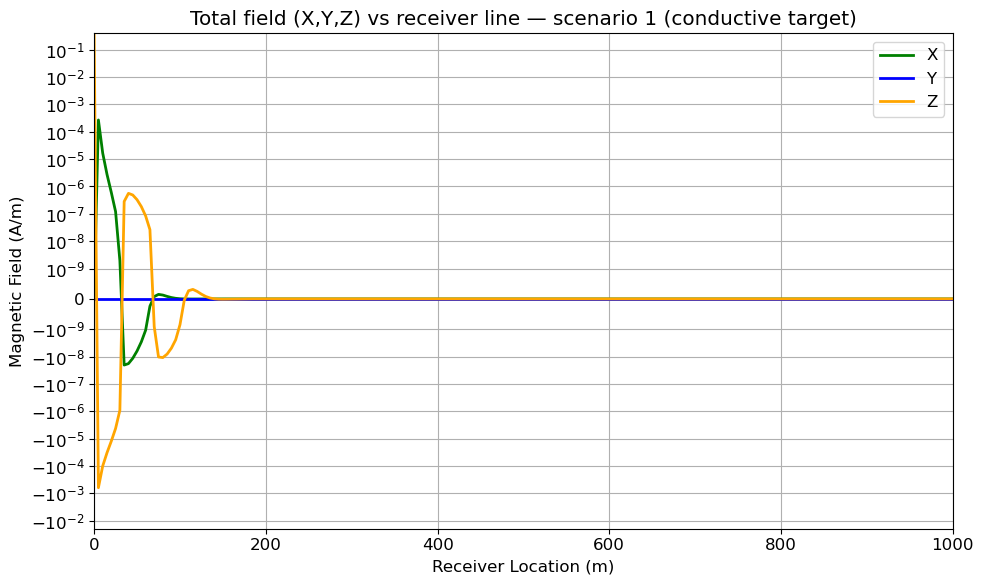

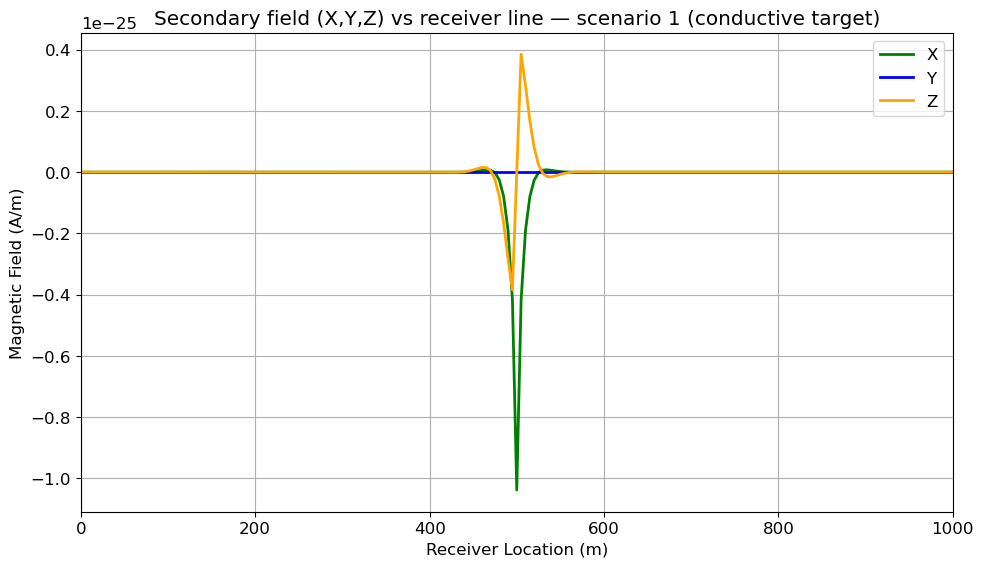

In [25]:
plot_total(out['conductive'], 'scenario 1 (conductive target)')
plot_secondary(out['conductive'], 'scenario 1 (conductive target)')

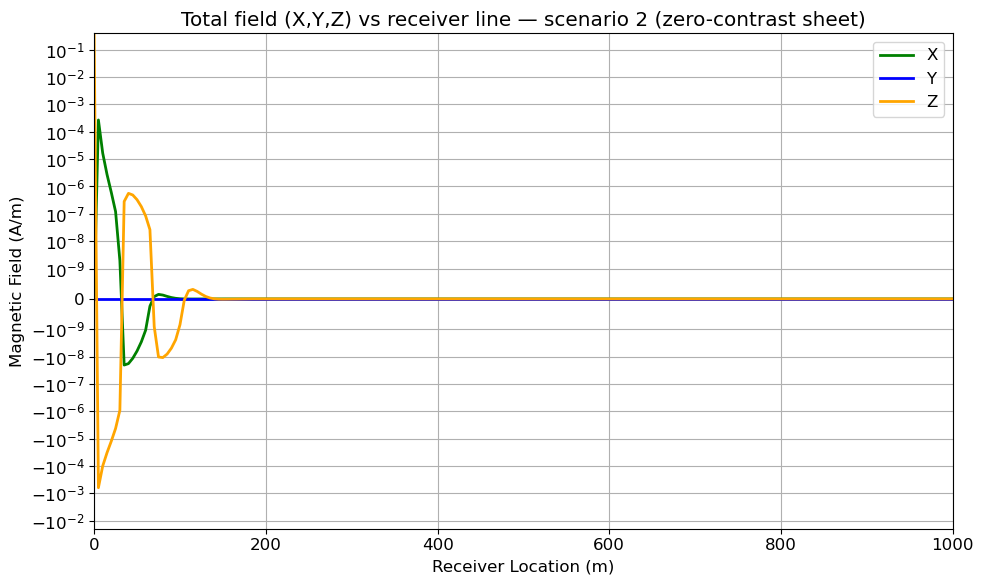

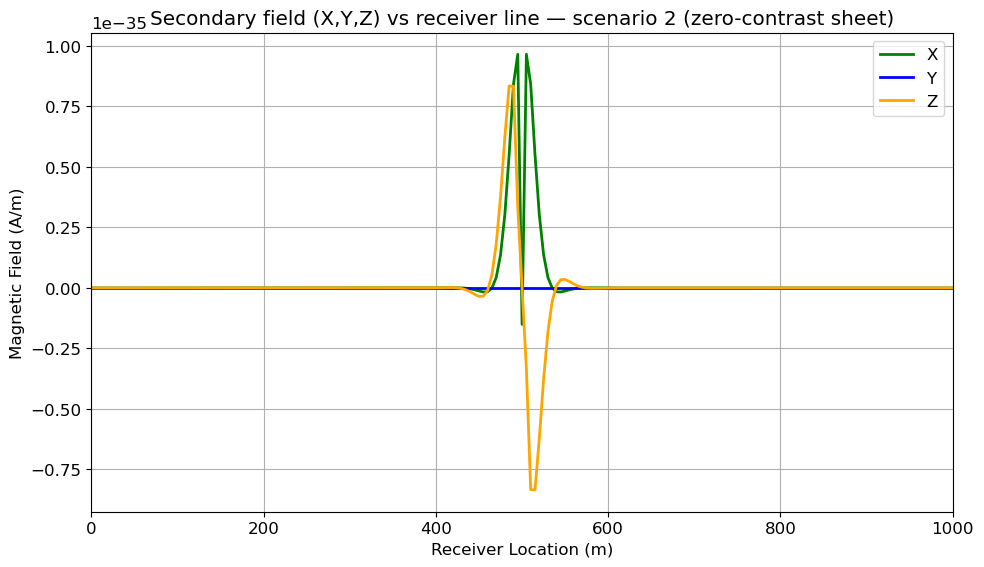

In [26]:
plot_total(out['zerocontrast'], 'scenario 2 (zero-contrast sheet)')
plot_secondary(out['zerocontrast'], 'scenario 2 (zero-contrast sheet)')

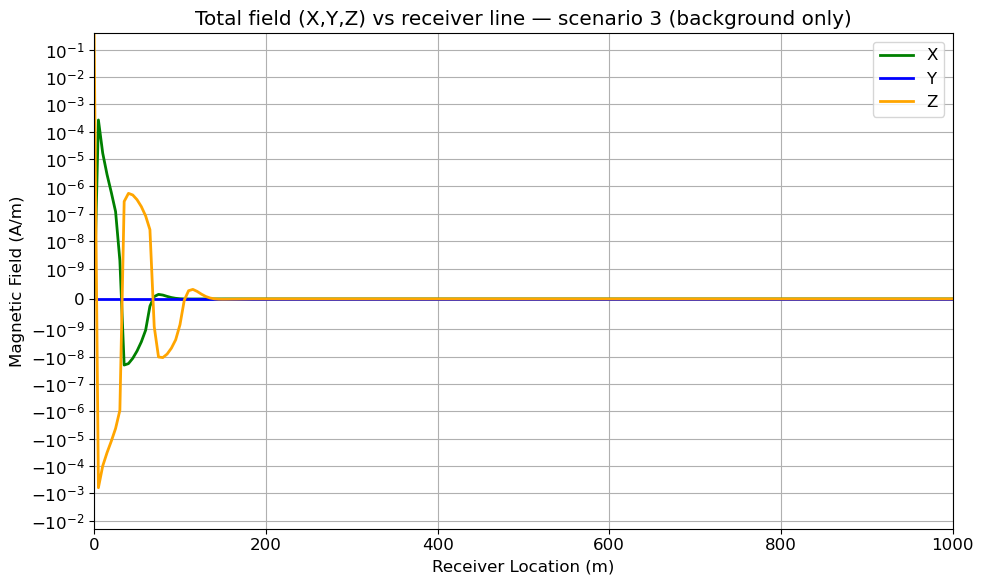

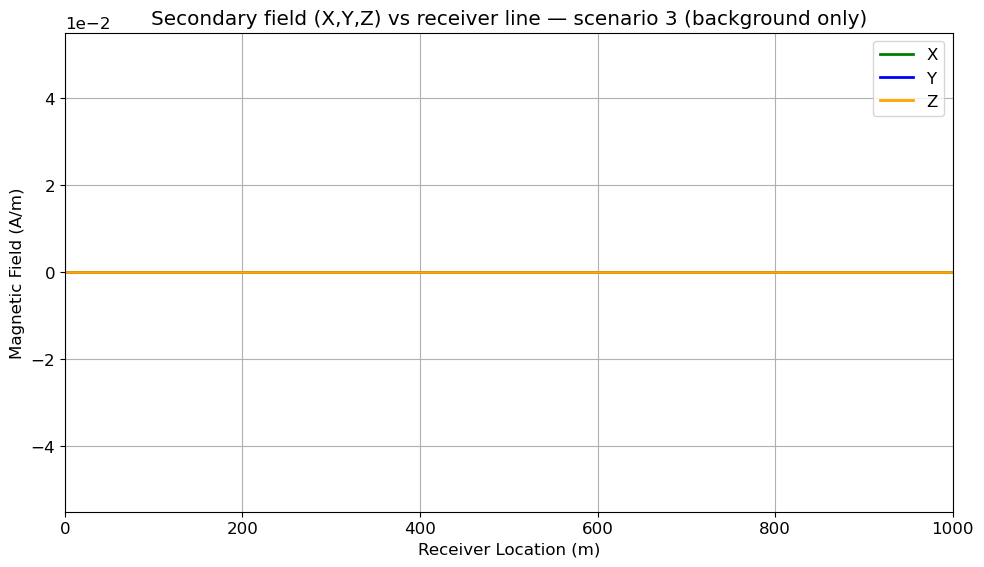

In [27]:
plot_total(out['background'], 'scenario 3 (background only)')
plot_secondary(out['background'], 'scenario 3 (background only)')